In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import session
import h5py
import pickle

In [2]:
# set the main data directory (this needs to be changed by each user)
maindir = '/Volumes/ExternalSSD/Credit_assignement'

In [3]:
# get all the sessions to analyze
mouse = 'M1'
layers = 'L23' #'L1'
sessionfile = open('M1_L23_Sessions.txt','r') #Or change this for the given mouse and Layers
allsessions = [sess.rstrip('\n') for sess in sessionfile.readlines()]
sessionfile.close()

In [4]:
print(allsessions)

['723322122', '721975393', '721032982', '720519615']


In [5]:
# create a dictionary with Session objects prepared for analysis
sdict = {}
for sess in allsessions:                       # remove the :1 to get all sessions ready
    print("\nCreating session {}...".format(sess))
    sdict[sess] = session.Session(maindir,sess)    # creates a session object to work with
    sdict[sess].extract_info()                     # extracts necessary info for analysis
    print("finished session {}.".format(sess))


Creating session 723322122...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_723322122
Loading running data...
Loading ROI trace info...



finished session 723322122.

Creating session 721975393...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_721975393
Loading running data...
Loading ROI trace info...



finished session 721975393.

Creating session 721032982...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exists in /Volumes/ExternalSSD/Credit_assignement/ophys_session_721032982
Loading running data...
Loading ROI trace info...



finished session 721032982.

Creating session 720519615...
Loading stimulus dictionary...
Loading alignment dataframe...
NOTE: Stimulus alignment pickle already exi

In [32]:
meansave = np.zeros([len(allsessions),5,8])
stdsave = np.zeros([len(allsessions),5,8])
for snum in range (0,len(allsessions)):
    S = allsessions[snum]
    print(S)
    
    #pull up h5 and df pkl files
    roifile = sdict[S].roi_traces
    twop = h5py.File(roifile,'r+')
    df_pkl_name = sdict[S].align_pkl
    file = open(df_pkl_name, 'rb')
    stim_p = pickle.load(file)
    file.close()
    stim_panda = stim_p['stim_df']

    #get df/f for Gabor frame "A","B","C","D"
    for gbframe in range(0,4):
        print(gbframe)
        gabor_segs = np.where((stim_panda['stimType'] == 'g') & (stim_panda['GABORFRAME'] == gbframe))
        gabor_starts = np.array(stim_panda['start_frame'][gabor_segs[0]])
        #gabor_ends = np.array(stim_panda['end_frame'][gabor_segs[0]])

        meanroi = np.zeros([len(gabor_starts),8])
        for i in range(0,len(gabor_starts)):
            meanroi[i,:] = np.nanmean(twop['data'][:,gabor_starts.item(i):gabor_starts.item(i)+8],axis=0)
        
        meansave[snum,gbframe,:] = np.nanmean(meanroi,axis=0)
        stdsave[snum,gbframe,:] = np.nanstd(meanroi,axis=0)/np.sqrt(1.0*i)    
        
        if gbframe==0:
            meanroi_blank = np.zeros([len(gabor_starts),8]) #just use this for gbframe 0
            for i in range(0,len(gabor_starts)):
                meanroi_blank[i,:] = np.nanmean(twop['data'][:,gabor_starts.item(i)-8:gabor_starts.item(i)],axis=0)
            meansave[snum,4,:] = np.nanmean(meanroi_blank,axis=0)
            stdsave[snum,4,:] = np.nanstd(meanroi_blank,axis=0)/np.sqrt(1.0*i) 
    

723322122
0
1
2
3
721975393
0
1
2
3
721032982
0
1
2
3
720519615
0
1
2
3


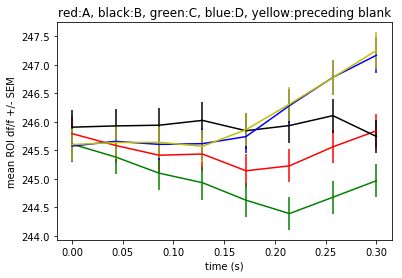

In [33]:
for snum in range (0,len(allsessions)):
    plt.errorbar(np.linspace(0,0.3,8),meansave[snum,0,:],stdsave[snum,0,:],color='r')
    plt.hold(True)
    plt.errorbar(np.linspace(0,0.3,8),meansave[snum,1,:],stdsave[snum,1,:],color='k')
    plt.errorbar(np.linspace(0,0.3,8),meansave[snum,2,:],stdsave[snum,2,:],color='g')
    plt.errorbar(np.linspace(0,0.3,8),meansave[snum,3,:],stdsave[snum,3,:],color='b')
    plt.errorbar(np.linspace(0,0.3,8),meansave[snum,4,:],stdsave[snum,4,:],color='y')
    plt.xlabel('time (s)')
    plt.ylabel('mean ROI df/f +/- SEM')
    plt.title('red:A, black:B, green:C, blue:D, yellow:preceding blank')
    plt.savefig('ROI_Analysis_'+mouse+'_Layer'+layers+'_GaborFrames_dff_SESS'+allsessions[snum],dpi=300)
    plt.hold(False)